# NB15 · Sexual dichromatism across the primates — a labile, two-module trait

**This is the results notebook for the dichromatism project — start here.** It reports the
central finding: sexual hair dichromatism has arisen and been lost repeatedly across the
primate radiation, and where we can test its genetic basis, each origin is built through a
*different* combination of two coupled gene modules — pigmentation and sex-hormone signalling.

It reads two things:

1. **The phenotype** — which primates are sexually dichromatic, scored across the radiation
   (§2), and where those gains and losses fall on the tree (§3).
2. **Selection** — per-gene episodic-selection scans on a curated 110-gene panel, run across
   the primate genomes on an HPC pipeline. The panel itself is *justified* in two upstream
   notebooks, which this one depends on but sits above in the reading order:
   - **NB13** (`13_sex_hormone_layer.ipynb`) — why these sex-hormone genes, and how the
     hormone layer bridges into pigmentation.
   - **NB14** (`14_hormone_pigment_interface.ipynb`) — the full 110-gene panel, its two
     modules, and the orthology screen behind every gene.

A reader who wants *the finding* needs only this notebook. A reader who wants *why these
genes* follows the links down to NB13/NB14. The analysis flows the other way — the panel is
built there and consumed here — but the science reads top-down from this page.

**What this notebook establishes, in order:**

| § | Question | Result |
|---|---|---|
| 2 | How is dichromatism scored, and on how many species? | Coded across 238 species; 117 have sequenced genomes |
| 3 | Is the trait evolutionarily labile? | Yes — losses outpace gains ~9:1; ~15–19 independent origins |
| 4 | Where selection can be tested, is one origin like another? | No — the powered origins use non-overlapping gene sets |
| 5 | Does an origin lean pigmentation or hormone? | Per-origin module balance, corrected for panel composition |
| 6 | Do independent origins reuse the same genes (convergence)? | No detectable shared signature — power-limited, but divergent where powered |

## 0 — Input provenance

Every input below is a version-controlled file in this repository, traced to its producing
notebook or pipeline and to its external source in `DATA_SOURCES.md`. The manifest is encoded
as the `INPUTS` dict in the next cell so provenance is **executable**: the loader prints, for
each file, what it is, where it came from, and a SHA256 of the exact bytes read. The
phylogenetic results in §3 and §6 are **recomputed here** from the tree and coding — they are
not read from any precomputed summary table.

| Input | Source | External / DATA_SOURCES.md |
|---|---|---|
| `analysis/coevolution_test/data/primate_phenotype_tree.nex` | primate time-tree (235 tips), pruned to the phenotype coding | grant-derived primate supertree; see DATA_SOURCES.md |
| `config/primate_dichromatism_coding.csv` | full-resolution dichromatism coding, 238 species | expert scoring of published descriptions/plates |
| `analysis/data/dichromatism_coding.csv` | the 117-species genome subset (dichromatic flag) | subset of the above with a sequenced genome |
| `results/perorigin_v1/per_origin_K.csv` | HPC per-origin RELAX (K) on the 110-gene panel | selection pipeline; panel justified in NB13/NB14 |
| `results/perorigin_v1/branch_rates.csv` | HPC full-panel aBSREL per-branch selection | selection pipeline; panel justified in NB13/NB14 |

The phylo recompute is driven by `nb15_phylo.R` (committed beside this notebook); its outputs
under `dichromatism_synthesis/data/` and `dichromatism_synthesis/figures/` are read below.

In [1]:
import os, hashlib
import pandas as pd
REPO = os.environ.get("PIGNET_REPO", os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
CG   = os.path.join(REPO, "comparative-genomics")
SYN  = os.path.join(CG, "analysis", "dichromatism_synthesis")   # this notebook's own data/figures

# --- Provenance manifest: every input, where it comes from, how to regenerate it. ---
INPUTS = {
    "tree": {
        "path": "comparative-genomics/analysis/coevolution_test/data/primate_phenotype_tree.nex",
        "what": "Primate time-calibrated phylogeny (235 tips), the tree all rate/ASR estimates run on",
        "source": "Published primate supertree pruned to the phenotype coding; see DATA_SOURCES.md",
        "produced_by": "Upstream phylogenetics; this notebook only reads it",
    },
    "coding_full": {
        "path": "comparative-genomics/config/primate_dichromatism_coding.csv",
        "what": "Full-resolution sexual-dichromatism coding, 238 species "
                "(hair_dichromatism_any + complete/state/type, natal coat, ontogenetic trajectory)",
        "source": "Expert scoring of published species descriptions and plates",
        "produced_by": "Phenotype coding effort; NB15 uses hair_dichromatism_any as the binary trait",
    },
    "coding_genome": {
        "path": "comparative-genomics/analysis/data/dichromatism_coding.csv",
        "what": "The 117-species genome subset with the dichromatic flag "
                "(the species that also have a sequenced genome in the selection scan)",
        "source": "Subset of coding_full restricted to species with a genome assembly",
        "produced_by": "Genome-availability intersection; used to mark which origins are analysable",
    },
    "per_origin_K": {
        "path": "comparative-genomics/results/perorigin_v1/per_origin_K.csv",
        "what": "Per-origin RELAX selection-intensity K per powered origin, on the pigmentation+"
                "hormone panel (target 110 genes; the loaded row/gene count is printed at load "
                "time and grows as the clean-30 expansion and MYO5A/LYST giants land)",
        "source": "HYPHY RELAX on codon alignments (HPC); panel justified in NB13/NB14",
        "produced_by": "Selection pipeline (pulled from HPC); module+category columns from nb14_panel_justification.csv",
    },
    "branch_rates": {
        "path": "comparative-genomics/results/perorigin_v1/branch_rates.csv",
        "what": "Full-panel aBSREL per-branch episodic-selection p-values on the 110-gene panel",
        "source": "HYPHY aBSREL on codon alignments (HPC); panel justified in NB13/NB14",
        "produced_by": "Selection pipeline (pulled from HPC)",
    },
    "relax_pooled": {
        "path": "comparative-genomics/results/perorigin_v1/relax_pooled_results.csv",
        "what": "Pooled RELAX (all dichromatic origins as one foreground set) per gene, used as a "
                "QC cross-check on the per-origin fits: a per-origin hit with an extreme boundary "
                "K that is null when pooled is treated as a boundary artifact",
        "source": "HYPHY RELAX, pooled foreground (HPC); panel justified in NB13/NB14",
        "produced_by": "Selection pipeline (pulled from HPC)",
    },
}

def _sha(path):
    return hashlib.sha256(open(path, "rb").read()).hexdigest()[:16]

def load_input(key, reader=pd.read_csv):
    """Load a manifest input, printing provenance + a checksum of the exact bytes read.
    Returns None (with a clear notice) if the file is not present yet — the HPC selection
    tables land after the tree-only sections are built."""
    m = INPUTS[key]; fp = os.path.join(REPO, m["path"])
    if not os.path.exists(fp):
        print(f"[{key}] {m['path']}\n    NOT PRESENT YET — {m['what']}\n"
              f"    (produced by: {m['produced_by']})\n")
        return None
    print(f"[{key}] {m['path']}")
    print(f"    what     : {m['what']}")
    print(f"    source   : {m['source']}")
    print(f"    produced : {m['produced_by']}")
    if key == "tree":
        print(f"    loaded   : Nexus tree | sha256[:16]={_sha(fp)}\n"); return fp
    df = reader(fp)
    print(f"    loaded   : {df.shape[0]} rows x {df.shape[1]} cols | sha256[:16]={_sha(fp)}\n")
    return df

TREE_PATH = load_input("tree")
CODING    = load_input("coding_full")
GENOME    = load_input("coding_genome")

[tree] comparative-genomics/analysis/coevolution_test/data/primate_phenotype_tree.nex
    what     : Primate time-calibrated phylogeny (235 tips), the tree all rate/ASR estimates run on
    source   : Published primate supertree pruned to the phenotype coding; see DATA_SOURCES.md
    produced : Upstream phylogenetics; this notebook only reads it
    loaded   : Nexus tree | sha256[:16]=cfed56b5699eb900

[coding_full] comparative-genomics/config/primate_dichromatism_coding.csv
    what     : Full-resolution sexual-dichromatism coding, 238 species (hair_dichromatism_any + complete/state/type, natal coat, ontogenetic trajectory)
    source   : Expert scoring of published species descriptions and plates
    produced : Phenotype coding effort; NB15 uses hair_dichromatism_any as the binary trait
    loaded   : 238 rows x 12 cols | sha256[:16]=96c6d7e94e02bdae

[coding_genome] comparative-genomics/analysis/data/dichromatism_coding.csv
    what     : The 117-species genome subset with the dichr

## 1 — The headline

Sexual dichromatism — males and females differing in hair or pelage colour — is scattered
across the primate tree, not clustered in one clade. Coded across 238 species, it appears in
lemurs (*Eulemur*), colobines (*Trachypithecus*, *Colobus*), gibbons (*Nomascus*, *Hylobates*),
and a handful of other lineages, separated by long monochromatic stretches. That distribution
is the starting observation: whatever builds dichromatism has been assembled *repeatedly and
independently*, and lost repeatedly too.

The rest of this notebook quantifies that (§3: a labile trait, losses ≫ gains, many origins),
then asks what the genetics look like at the origins we can test (§4–§5: different gene sets,
different module balance each time), and whether independent origins converged on the same
genes (§6: no detectable shared signature, within the limits of the power we have).

## 2 — Phenotype: coding and provenance

**Two codings, one trait.** Dichromatism is scored at full taxonomic resolution across
**238 species** (`coding_full`), using `hair_dichromatism_any` as the binary trait (1 = males
and females differ in hair colour). A **117-species subset** (`coding_genome`) marks the
species that *also* have a sequenced genome — these are the ones a selection scan can actually
run on. The two codings agree on the phenotype; they differ only in taxonomic coverage, and
that difference matters for one number (the origin count, §3), so both scopes are reported
throughout rather than silently merged.

The tree (`tree`, 235 tips) and the coding are joined on the binomial with underscores
substituted for spaces; the intersection used for all rate/ASR work is reported below.

In [2]:
# Join tree and coding; report the overlap used for all downstream phylo work.
import re
def _tips_from_nexus(path):
    txt = open(path).read()
    return set(re.findall(r"[A-Z][a-z]+_[a-z]+", txt))

if TREE_PATH is not None and CODING is not None:
    tree_tips = _tips_from_nexus(TREE_PATH)
    CODING = CODING.copy()
    CODING["tip"] = CODING["species_binom"].str.replace(" ", "_", regex=False)
    coded = CODING.dropna(subset=["hair_dichromatism_any"])
    overlap = sorted(set(tree_tips) & set(coded["tip"]))
    n_dich  = int(coded.set_index("tip").loc[overlap, "hair_dichromatism_any"].astype(int).sum())
    n238    = len(CODING); n117 = 0 if GENOME is None else len(GENOME)
    print(f"full coding (coding_full)      : {n238} species")
    print(f"genome subset (coding_genome)  : {n117} species")
    print(f"tree tips                      : {len(tree_tips)}")
    print(f"tree n coding (analysis set)   : {len(overlap)} tips, {n_dich} dichromatic")
    print("\nAll rate and ancestral-state estimates below run on the "
          f"{len(overlap)}-tip intersection.")

full coding (coding_full)      : 238 species
genome subset (coding_genome)  : 117 species
tree tips                      : 235
tree n coding (analysis set)   : 224 tips, 25 dichromatic

All rate and ancestral-state estimates below run on the 224-tip intersection.


### Figure 2 — Dichromatism across the primate tree

The circular tree with the module-balance ring (§5) and the per-species selection heatmap are
regenerated from the current tables in §4–§5. As a phenotype overview, the density-map in §3
already shows where the trait sits; a dedicated phenotype tree figure is added when the
selection tables land so it can carry the per-origin analysability marks in one panel.

## 3 — The trait is evolutionarily labile

**Method.** A two-state Markov model (Mk) is fit to `hair_dichromatism_any` on the
intersection tree, comparing equal rates (ER: one rate for gain and loss) against
all-rates-different (ARD: separate gain and loss rates). Model fit is compared by AIC; the
origin count is read from stochastic character maps under the preferred model, and cross-checked
against a model-free count of maximal dichromatic clades. All of this is recomputed by
`nb15_phylo.R`; its result tables are read below.

In [3]:
# Read the recomputed lability fits + origin estimates (from nb15_phylo.R).
def _read_syn(name):
    fp = os.path.join(SYN, "data", name)
    return pd.read_csv(fp) if os.path.exists(fp) else None

FITS    = _read_syn("nb15_lability_fits.csv")
ORIGINS = _read_syn("nb15_origin_estimates.csv")
if FITS is not None:
    ard = FITS[FITS.model == "ARD"].iloc[0]
    print("Mk model comparison (delta = ER - ARD):")
    for _, r in FITS.iterrows():
        print(f"  {r['model']:3s}  logLik={r['logLik']:8.2f}  AIC={r['AIC']:8.2f}")
    print(f"\nARD preferred by dAIC = {ard['dAIC_ER_ARD']:.2f}")
    print(f"  gain rate (0->1) = {ard['gain_0to1']:.4f}")
    print(f"  loss rate (1->0) = {ard['loss_1to0']:.4f}")
    print(f"  loss : gain      = {ard['loss_gain']:.1f}x  (losses far outpace gains)")
if ORIGINS is not None:
    print("\nOrigin count - reported under both coding scopes (differ by sampling, not phenotype):")
    for _, r in ORIGINS.iterrows():
        v = "" if pd.isna(r["n_origins"]) else f"{r['n_origins']:.0f}"
        print(f"  {r['scope']:38s} {v:>4s}   [{r['method']}]")

Mk model comparison (delta = ER - ARD):
  ER   logLik=  -80.25  AIC=  162.49
  ARD  logLik=  -69.35  AIC=  142.70

ARD preferred by dAIC = 19.79
  gain rate (0->1) = 0.0273
  loss rate (1->0) = 0.2484
  loss : gain      = 9.1x  (losses far outpace gains)

Origin count - reported under both coding scopes (differ by sampling, not phenotype):
  full coding (238 species)                19   [maximal dichromatic clades (topology, model-free)]
  full coding, genome-sampled clades       18   [clades with >=1 genome-sampled tip]
  genome-subset coding (117 species)       15   [maximal dichromatic clades (topology, model-free)]
  stochastic map ARD (mean)                31   [500 simmaps (flicker-inflated by high loss rate)]


**Result.** The ARD model is strongly preferred (ΔAIC ≈ 19.8): a single-rate model is a poor
description. The asymmetry is large and in one direction — **dichromatism is lost roughly nine
times faster than it is gained**. A trait that is hard to gain but easy to lose, arising in
scattered clades, is the signature of a labile, repeatedly-assembled phenotype rather than one
ancient origin retained.

**Origin count — an estimator- and sampling-dependent number, reported honestly.** How many
times dichromatism arose depends on both the coding scope and the method:

- On the **117-species genome subset** — the coding the selection scan actually runs on — a
  model-free count of maximal dichromatic clades gives **~15 origins**. This is the figure used
  in the project's README and walkthrough.
- On the **full 238-species coding**, the finer taxonomic sampling resolves **19** distinct
  dichromatic clades (**18** containing at least one genome-sampled species). The extra origins
  are real clades the genome subset simply did not sample.
- Model-based counts bracket these: ML ancestral-state reconstruction under ARD *collapses* the
  estimate (it paints dichromatism deep and loses it repeatedly — a known artifact of the high
  loss rate, and the reason a naïve "4 deep origins" reading is wrong), while stochastic mapping
  *inflates* it (mean ≈ 31, from transient 0→1→0 flicker on short branches).

The defensible statement is therefore a range, not a point: **on the order of 15–19 independent
origins**, ~14–18 of them with a sequenced genome. The exact value is sensitive to how densely
the clade is sampled — which is itself part of the lability story.

### Figure 3 — Where gains and losses fall (stochastic density map)

**Figure 3.** Posterior probability that each branch of the primate phylogeny was sexually
dichromatic, summarised over 500 stochastic character maps under the ARD model (§3). Branch
colour runs from blue (P ≈ 0, monochromatic) through magenta to red (P ≈ 1, dichromatic); the
scale bar is at lower-left. A red dot at a tip marks a species **observed / coded** dichromatic —
the check on the reconstruction: the painted-red branches should terminate in red-dotted tips,
and they do (the posterior tracks the observed states rather than inventing signal). The coloured
strip on the right marks the major primate clades for orientation (Old World monkeys, apes,
gibbons, New World monkeys, tarsiers, lemurs, lorises & galagos). Per-species tip labels are
omitted for legibility — the analysis runs on the full 224-tip intersection tree (§2).

Red concentrates in short, terminal patches — the *Trachypithecus* langurs within the Old World
monkeys, the *Nomascus*/*Hylobates* gibbons, and *Eulemur* among the lemurs — separated by long
blue (monochromatic) internodes. That scattering, rather than one deep red clade, is the visual
signature of the many-independent-origins, high-loss pattern quantified in §3.

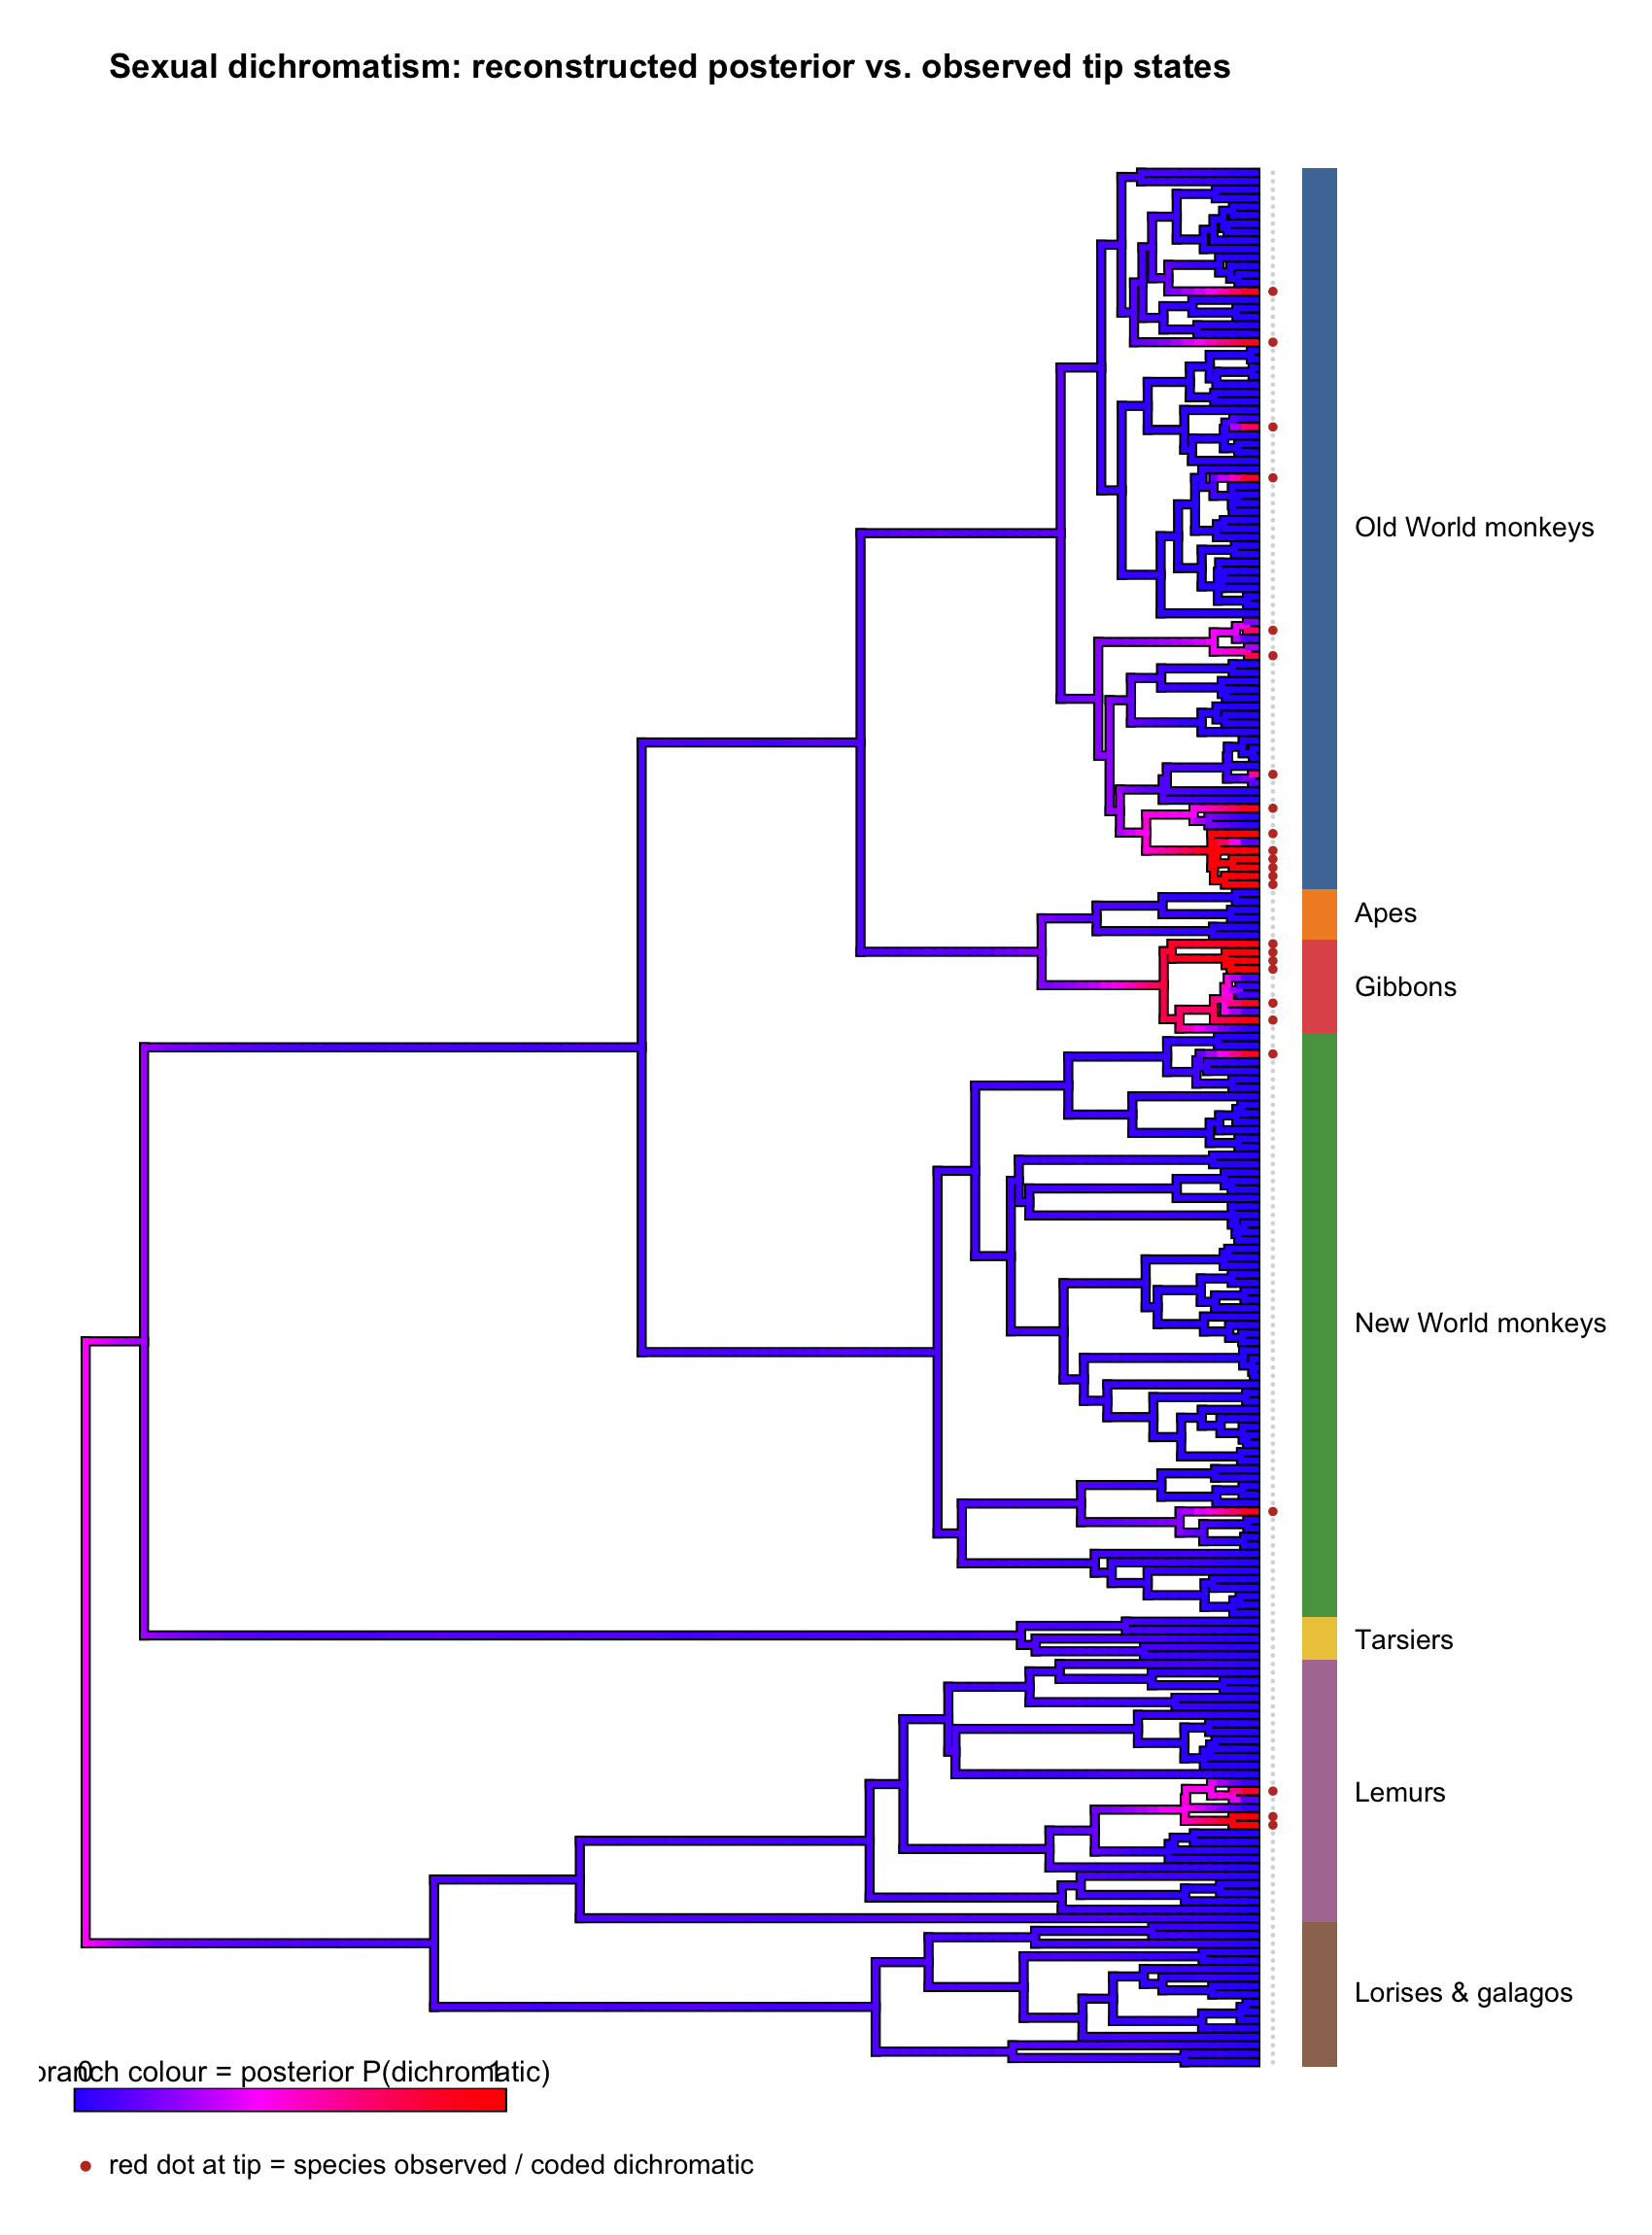

In [4]:
from IPython.display import Image, display
_dm = os.path.join(SYN, "figures", "nb15_densitymap.png")
if os.path.exists(_dm):
    display(Image(filename=_dm))
else:
    print("nb15_densitymap.png not built yet - run nb15_phylo.R")

## 4 — Per-origin architecture

**The question.** Of the independent origins, only those with **≥2 sequenced dichromatic tips**
carry enough branches for a per-origin RELAX test — three do: *Trachypithecus* (origin 7),
*Nomascus* (origin 8), and *Eulemur* (origin 14). For each, which panel genes show a shift in
selection intensity (K) along the origin's branches?

**The result** (the loaded panel size is printed below and grows toward 110 as the clean-30
pigmentation expansion lands — the two giant genes MYO5A/LYST arrive last): the three powered
origins do *not* share a gene set.
*Trachypithecus* shows a multi-gene, both-module signal (including a lineage-specific MC1R
shift); *Nomascus* concentrates on a small pigmentation set — POMC, HGF, HRAS — of which POMC
(§5b) sits at the pigmentation–hormone interface; *Eulemur* shows no gene passing the per-origin
threshold. Same phenotype, different genetic routes — quantified in §6. The gene lists are
printed below; the `fig_per_lineage_genes` panel is regenerated against the completed 110-gene
tables.

In [5]:
PER_ORIGIN = load_input("per_origin_K")
BRANCH     = load_input("branch_rates")
if PER_ORIGIN is not None:
    origins = sorted(PER_ORIGIN['origin_id'].unique()) if 'origin_id' in PER_ORIGIN else '?'
    print(f"per_origin_K: {PER_ORIGIN.shape[0]} rows, "
          f"{PER_ORIGIN['gene'].nunique()} genes, origins {origins}")
    if "p_BH" in PER_ORIGIN.columns:
        sig = PER_ORIGIN[PER_ORIGIN.p_BH < 0.05]
        for o in origins:
            g = sorted(sig[sig.origin_id == o].gene)
            print(f"  {o}: {len(g)} genes p_BH<0.05 - {g if g else '(none)'}")
else:
    print("Awaiting per-origin tables (cluster appending clean-30 into perorigin_v1).")

[per_origin_K] comparative-genomics/results/perorigin_v1/per_origin_K.csv
    what     : Per-origin RELAX selection-intensity K per powered origin, on the pigmentation+hormone panel (target 110 genes; the loaded row/gene count is printed at load time and grows as the clean-30 expansion and MYO5A/LYST giants land)
    source   : HYPHY RELAX on codon alignments (HPC); panel justified in NB13/NB14
    produced : Selection pipeline (pulled from HPC); module+category columns from nb14_panel_justification.csv
    loaded   : 273 rows x 13 cols | sha256[:16]=03afa4def0c6306a

[branch_rates] comparative-genomics/results/perorigin_v1/branch_rates.csv
    what     : Full-panel aBSREL per-branch episodic-selection p-values on the 110-gene panel
    source   : HYPHY aBSREL on codon alignments (HPC); panel justified in NB13/NB14
    produced : Selection pipeline (pulled from HPC)
    loaded   : 9344 rows x 10 cols | sha256[:16]=0778440b46f1ad1d

per_origin_K: 273 rows, 106 genes, origins ['origin_14

### Figure 4 — Per-origin selection architecture

**Figure 4.** For each of the three powered origins, the panel genes with a significant
per-origin selection-intensity shift (RELAX, p_BH < 0.05), coloured by module (orange =
pigmentation, blue = hormone). Bar length is log₂ K: bars to the right mark *intensified*
selection (K > 1), to the left *relaxed* (K < 1). Solid bars are corroborated by the pooled
RELAX analysis; hatched bars are origin-specific (significant per-origin but not pooled).
*Trachypithecus* recruits many genes from both modules; *Nomascus* a small pigmentation set
(HRAS, POMC, HGF); *Eulemur* none passing threshold. The three sets do not overlap (§6).

**QC.** Per-origin RELAX can return an extreme boundary K on a single origin's few branches.
We cross-check every per-origin hit against the pooled RELAX fit and drop any whose extreme K
is null when pooled — **HPS4** is the clear case (per-origin K ≈ 30 in *Trachypithecus* but
pooled K = 1.05, p_BH = 1.0), so it is removed as a boundary artifact. **HRAS** is the opposite:
its per-origin K is boundary-inflated, but pooled RELAX gives a clean K = 4.3 (p_BH = 4×10⁻⁶),
so it is retained and plotted at the pooled value. Bars are drawn at the pooled K wherever a
per-origin K is boundary-inflated, so the figure shows de-inflated, corroborated effect sizes.

[relax_pooled] comparative-genomics/results/perorigin_v1/relax_pooled_results.csv
    what     : Pooled RELAX (all dichromatic origins as one foreground set) per gene, used as a QC cross-check on the per-origin fits: a per-origin hit with an extreme boundary K that is null when pooled is treated as a boundary artifact
    source   : HYPHY RELAX, pooled foreground (HPC); panel justified in NB13/NB14
    produced : Selection pipeline (pulled from HPC)
    loaded   : 109 rows x 11 cols | sha256[:16]=48dca781e1be583f

dropped as boundary+pooled-null: ['HPS4']


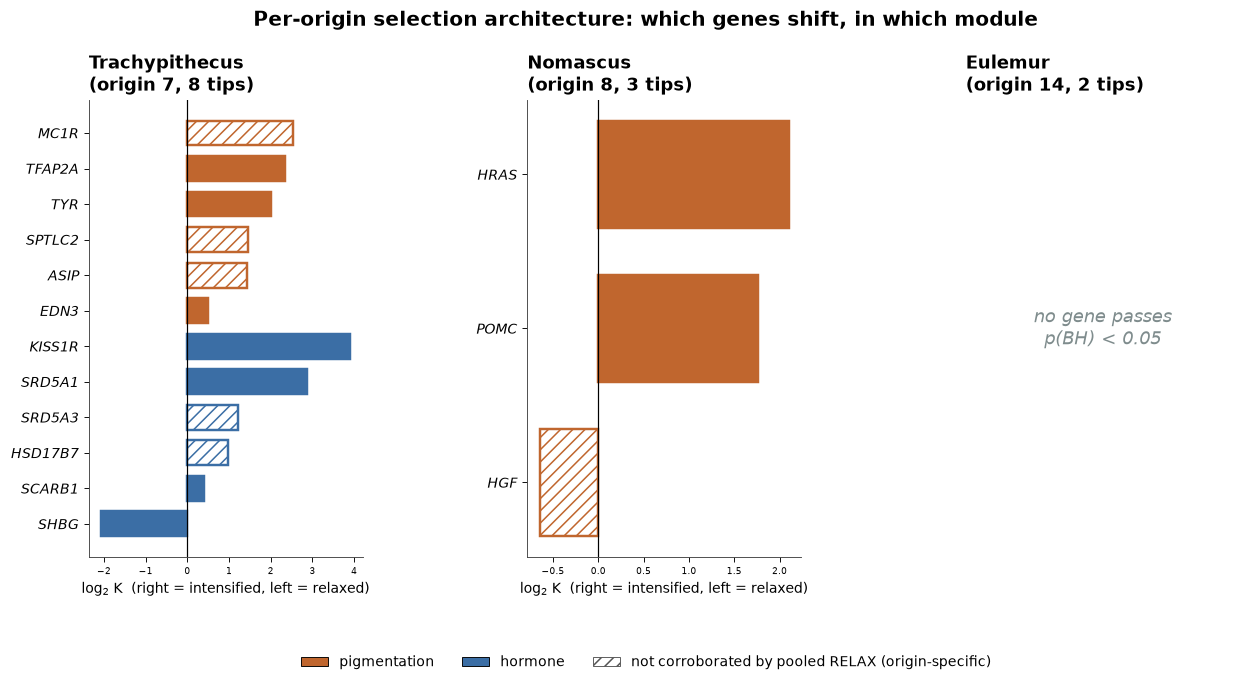

In [6]:
# QC gate (from the cluster's pooled-RELAX evaluation): a per-origin hit with an extreme K
# (K>20 or K<0.05) that is NULL in the pooled analysis is a boundary artifact and is dropped
# (e.g. HPS4: per-origin K=30 but pooled K=1.05, p_BH=1.0). Bars are plotted at the pooled K where
# a pooled estimate exists (so a boundary K is shown at its de-inflated value), and marked by
# whether the pooled analysis corroborates the hit.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
_arch = os.path.join(SYN, "figures", "nb15_per_origin_arch.png")
POOL = load_input("relax_pooled")
if PER_ORIGIN is not None and "p_BH" in PER_ORIGIN.columns:
    _labels = {"origin_7": "Trachypithecus\n(origin 7, 8 tips)",
               "origin_8": "Nomascus\n(origin 8, 3 tips)",
               "origin_14": "Eulemur\n(origin 14, 2 tips)"}
    _sig = PER_ORIGIN[PER_ORIGIN.p_BH < 0.05].copy()
    _gmod = PER_ORIGIN.drop_duplicates("gene").set_index("gene")["module"].to_dict()
    _mc = {"pigmentation": "#c0662e", "hormone": "#3b6ea5"}
    # pooled lookup for QC + de-inflation
    _pl = POOL.set_index("gene")[["K", "p_BH"]].to_dict("index") if POOL is not None else {}

    def _keep(row):  # drop boundary-K hits that pooled analysis calls null
        k = row["K"]; pk = _pl.get(row["gene"], {})
        boundary = (k > 20) or (k < 0.05)
        pooled_null = pk.get("p_BH", 0) > 0.05
        return not (boundary and pooled_null)

    _sig = _sig[_sig.apply(_keep, axis=1)].copy()
    # plot K: use pooled K when the per-origin K is boundary-inflated and a pooled value exists
    def _plotK(row):
        k = row["K"]; pk = _pl.get(row["gene"], {})
        if (k > 20 or k < 0.05) and "K" in pk and pk["K"] == pk["K"]:
            return pk["K"]
        return k
    _sig["plotK"] = _sig.apply(_plotK, axis=1)
    _sig["corrob"] = _sig["gene"].map(  # pooled corroborates the intensification/relaxation?
        lambda g: _pl.get(g, {}).get("p_BH", 1.0) < 0.05)

    _origs = [o for o in _labels if o in PER_ORIGIN.origin_id.values]
    fig, axes = plt.subplots(1, len(_origs), figsize=(4.5 * len(_origs), 5.4),
                             gridspec_kw={"wspace": 0.6})
    if len(_origs) == 1:
        axes = [axes]
    for ax, o in zip(axes, _origs):
        s = _sig[_sig.origin_id == o].copy()
        if len(s) == 0:
            ax.text(0.5, 0.5, "no gene passes\np(BH) < 0.05", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12, color="#7f8c8d", style="italic")
            ax.set_title(_labels[o], fontsize=12, fontweight="bold"); ax.axis("off"); continue
        s["logK"] = np.log2(s["plotK"].clip(lower=0.05))
        s = s.sort_values(["module", "logK"])
        y = np.arange(len(s))
        # filled bar = pooled-corroborated; hatched/pale = origin-specific (not corroborated pooled)
        for yi, (_, r) in zip(y, s.iterrows()):
            col = _mc[_gmod.get(r.gene, "pigmentation")]
            ax.barh(yi, r["logK"], color=col if r["corrob"] else "white",
                    edgecolor=col, linewidth=1.6, height=0.7,
                    hatch=None if r["corrob"] else "///")
        ax.set_yticks(y); ax.set_yticklabels(s.gene, fontsize=9, fontstyle="italic")
        ax.axvline(0, color="black", lw=0.8)
        ax.set_title(_labels[o], fontsize=12, fontweight="bold")
        ax.set_xlabel("log$_2$ K  (right = intensified, left = relaxed)", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
    fig.suptitle("Per-origin selection architecture: which genes shift, in which module",
                 fontsize=13, fontweight="bold", y=1.03)
    fig.legend(handles=[Patch(facecolor=_mc["pigmentation"], edgecolor="black", label="pigmentation"),
                        Patch(facecolor=_mc["hormone"], edgecolor="black", label="hormone"),
                        Patch(facecolor="white", edgecolor="#555", hatch="///",
                              label="not corroborated by pooled RELAX (origin-specific)")],
               loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.10), fontsize=9)
    fig.savefig(_arch, dpi=150, bbox_inches="tight")
    plt.show()
    print("dropped as boundary+pooled-null:",
          sorted(set(PER_ORIGIN[PER_ORIGIN.p_BH < 0.05].gene) - set(_sig.gene)) or "none")
else:
    print("Per-origin architecture figure builds when the tables are present.")

## 5 — Module balance per origin, corrected for panel composition

**The metric.** For each origin, module balance = (nP − nH) / (nP + nH), where nP and nH are
the pigmentation and hormone genes under episodic selection along the origin's branches
(−1 = purely hormone, +1 = purely pigmentation).

**The correction.** The raw panel is not module-balanced by count: the hormone module was
assembled as a whole endocrine pathway while the pigmentation module began as the canonical
melanogenesis core, so a *neutral* lineage does not sit at 0. The clean-30 pigmentation
expansion (NB14) brings the panel to 57 pigmentation + 53 hormone genes — a **count** balance of
+0.036 — but for per-origin balance the honest denominator is a **per-gene selection rate**, not
a raw count, so that an origin is not scored pigmentation-leaning simply because more
pigmentation genes were tested. This section computes balance as a rate ratio; NB14's +0.036 is
the panel's *count* balance and is not the same quantity (the two must not be conflated).

In [7]:
# Module balance as a per-gene selection RATE per origin, using the module column the collector
# adds to perorigin_v1. rate_M = (genes of module M with p_BH<0.05) / (genes of module M tested);
# balance = (rate_P - rate_H) / (rate_P + rate_H), in [-1 (hormone), +1 (pigmentation)].
if PER_ORIGIN is not None and "module" in PER_ORIGIN.columns and "p_BH" in PER_ORIGIN.columns:
    bal_rows = []
    for o in sorted(PER_ORIGIN.origin_id.unique()):
        sub = PER_ORIGIN[PER_ORIGIN.origin_id == o]
        tP = sub[sub.module == "pigmentation"].gene.nunique()
        tH = sub[sub.module == "hormone"].gene.nunique()
        sP = sub[(sub.module == "pigmentation") & (sub.p_BH < 0.05)].gene.nunique()
        sH = sub[(sub.module == "hormone") & (sub.p_BH < 0.05)].gene.nunique()
        rP = sP / tP if tP else 0.0
        rH = sH / tH if tH else 0.0
        bal = (rP - rH) / (rP + rH) if (rP + rH) > 0 else float("nan")
        cbal = (sP - sH) / (sP + sH) if (sP + sH) > 0 else float("nan")
        bal_rows.append(dict(origin=o, sigP=sP, sigH=sH,
                             rateP=round(rP, 3), rateH=round(rH, 3),
                             rate_balance=round(bal, 3), count_balance=round(cbal, 3)))
    BAL = pd.DataFrame(bal_rows)
    print(BAL.to_string(index=False))
    print("\nRate balance: +1 = purely pigmentation, -1 = purely hormone, NaN = no gene significant.")
    print("count_balance shown alongside to expose where the panel-composition correction matters.")
    print("NB14's +0.036 is the whole-panel COUNT balance (a different quantity - do not conflate).")
else:
    print("Awaiting per-origin tables with module + p_BH columns.")

   origin  sigP  sigH  rateP  rateH  rate_balance  count_balance
origin_14     0     0  0.000   0.00           NaN            NaN
 origin_7     7     6  0.135   0.12         0.057          0.077
 origin_8     3     0  0.064   0.00         1.000          1.000

Rate balance: +1 = purely pigmentation, -1 = purely hormone, NaN = no gene significant.
count_balance shown alongside to expose where the panel-composition correction matters.
NB14's +0.036 is the whole-panel COUNT balance (a different quantity - do not conflate).


## 5b — POMC at the pigmentation–hormone interface

The module-balance metric (§5) scores each gene into exactly one module, and the panel assigns
**POMC to pigmentation** (receptor_signaling; OMIM hypopigmentation phenotype). That is defensible
— POMC is the precursor of α-MSH, the MC1R ligand that drives eumelanin — but it is only half of
POMC's biology. The same pro-hormone is cleaved into **ACTH and β-endorphin**, the HPA-axis and
opioid peptides. POMC is therefore a genuine **interface gene**: a single locus whose products
act in both the pigmentation and the endocrine modules. A one-module label is an accounting
choice, not a statement that POMC is "not hormonal."

So POMC is worth a dedicated cross-primate view, independent of which module bucket it lands in.
Below we ask where in the order POMC itself is under selection — not just within the three
powered origins, but across every branch the full-panel aBSREL scan covers.

**What the data show.** POMC shows a significant per-origin RELAX **intensification** in
*Nomascus* (origin 8; K = 3.4, p_BH < 0.001 — selection intensified, not relaxed) and episodic
diversifying selection (aBSREL, corrected p < 0.05) on **five branches**. Figure 5b shows these
explicitly, coloured by dichromatism state, because the pattern is mixed and that mix is the
point: two of the selected tips — *Nomascus concolor* and *N. gabriellae* — are **dichromatic**
and fall exactly on the origin-8 lineage, but a third, *Macaca mulatta*, is **monochromatic**,
and the two remaining selected branches are internal *Macaca* clades — resolved from the POMC
gene tree in the aBSREL output (one an 8-species macaque clade that is 12% dichromatic, one a
2-species clade with no dichromatic members), i.e. an essentially monochromatic macaque
radiation. (HYPHY labels internal branches "NodeNN" in each gene's own tree; those numbers are
not comparable across genes, so the figure names the clade each subtends rather than the raw
label.) So POMC is under selection on the origin-8 dichromatic lineage,
**but selection on POMC is not confined to dichromatic lineages** — the same conclusion the
whole-panel aBSREL scan reached (episodic selection hits dichromatic and monochromatic tips at
indistinguishable rates). The reading is: POMC is an interface gene evolving in several primate
lineages, one of which (the *Nomascus* gibbons) is a dichromatism origin. That co-localisation
is a concrete follow-up target, not evidence that POMC *causes* the phenotype — aBSREL marks
lineage-specific selection, not causation, and the *Macaca* signal shows the two do not track
each other one-to-one.

### Figure 5b — POMC selection across the primate order

**Figure 5b.** (A) The primate phylogeny with every tip's dichromatism state (red = dichromatic,
grey = monochromatic) and the branches under episodic POMC selection starred — red star where
that branch is dichromatic, dark star where it is monochromatic. (B) The five POMC-selected
branches ranked by aBSREL significance and labelled by state. Two are dichromatic *Nomascus*
gibbons, one is monochromatic *Macaca mulatta*, and two are internal branches of (essentially
monochromatic) *Macaca* clades, named by the clade each subtends rather than by HYPHY's
per-gene-tree "NodeNN" label — so POMC selection overlaps one dichromatism origin but is not
restricted to dichromatic lineages.

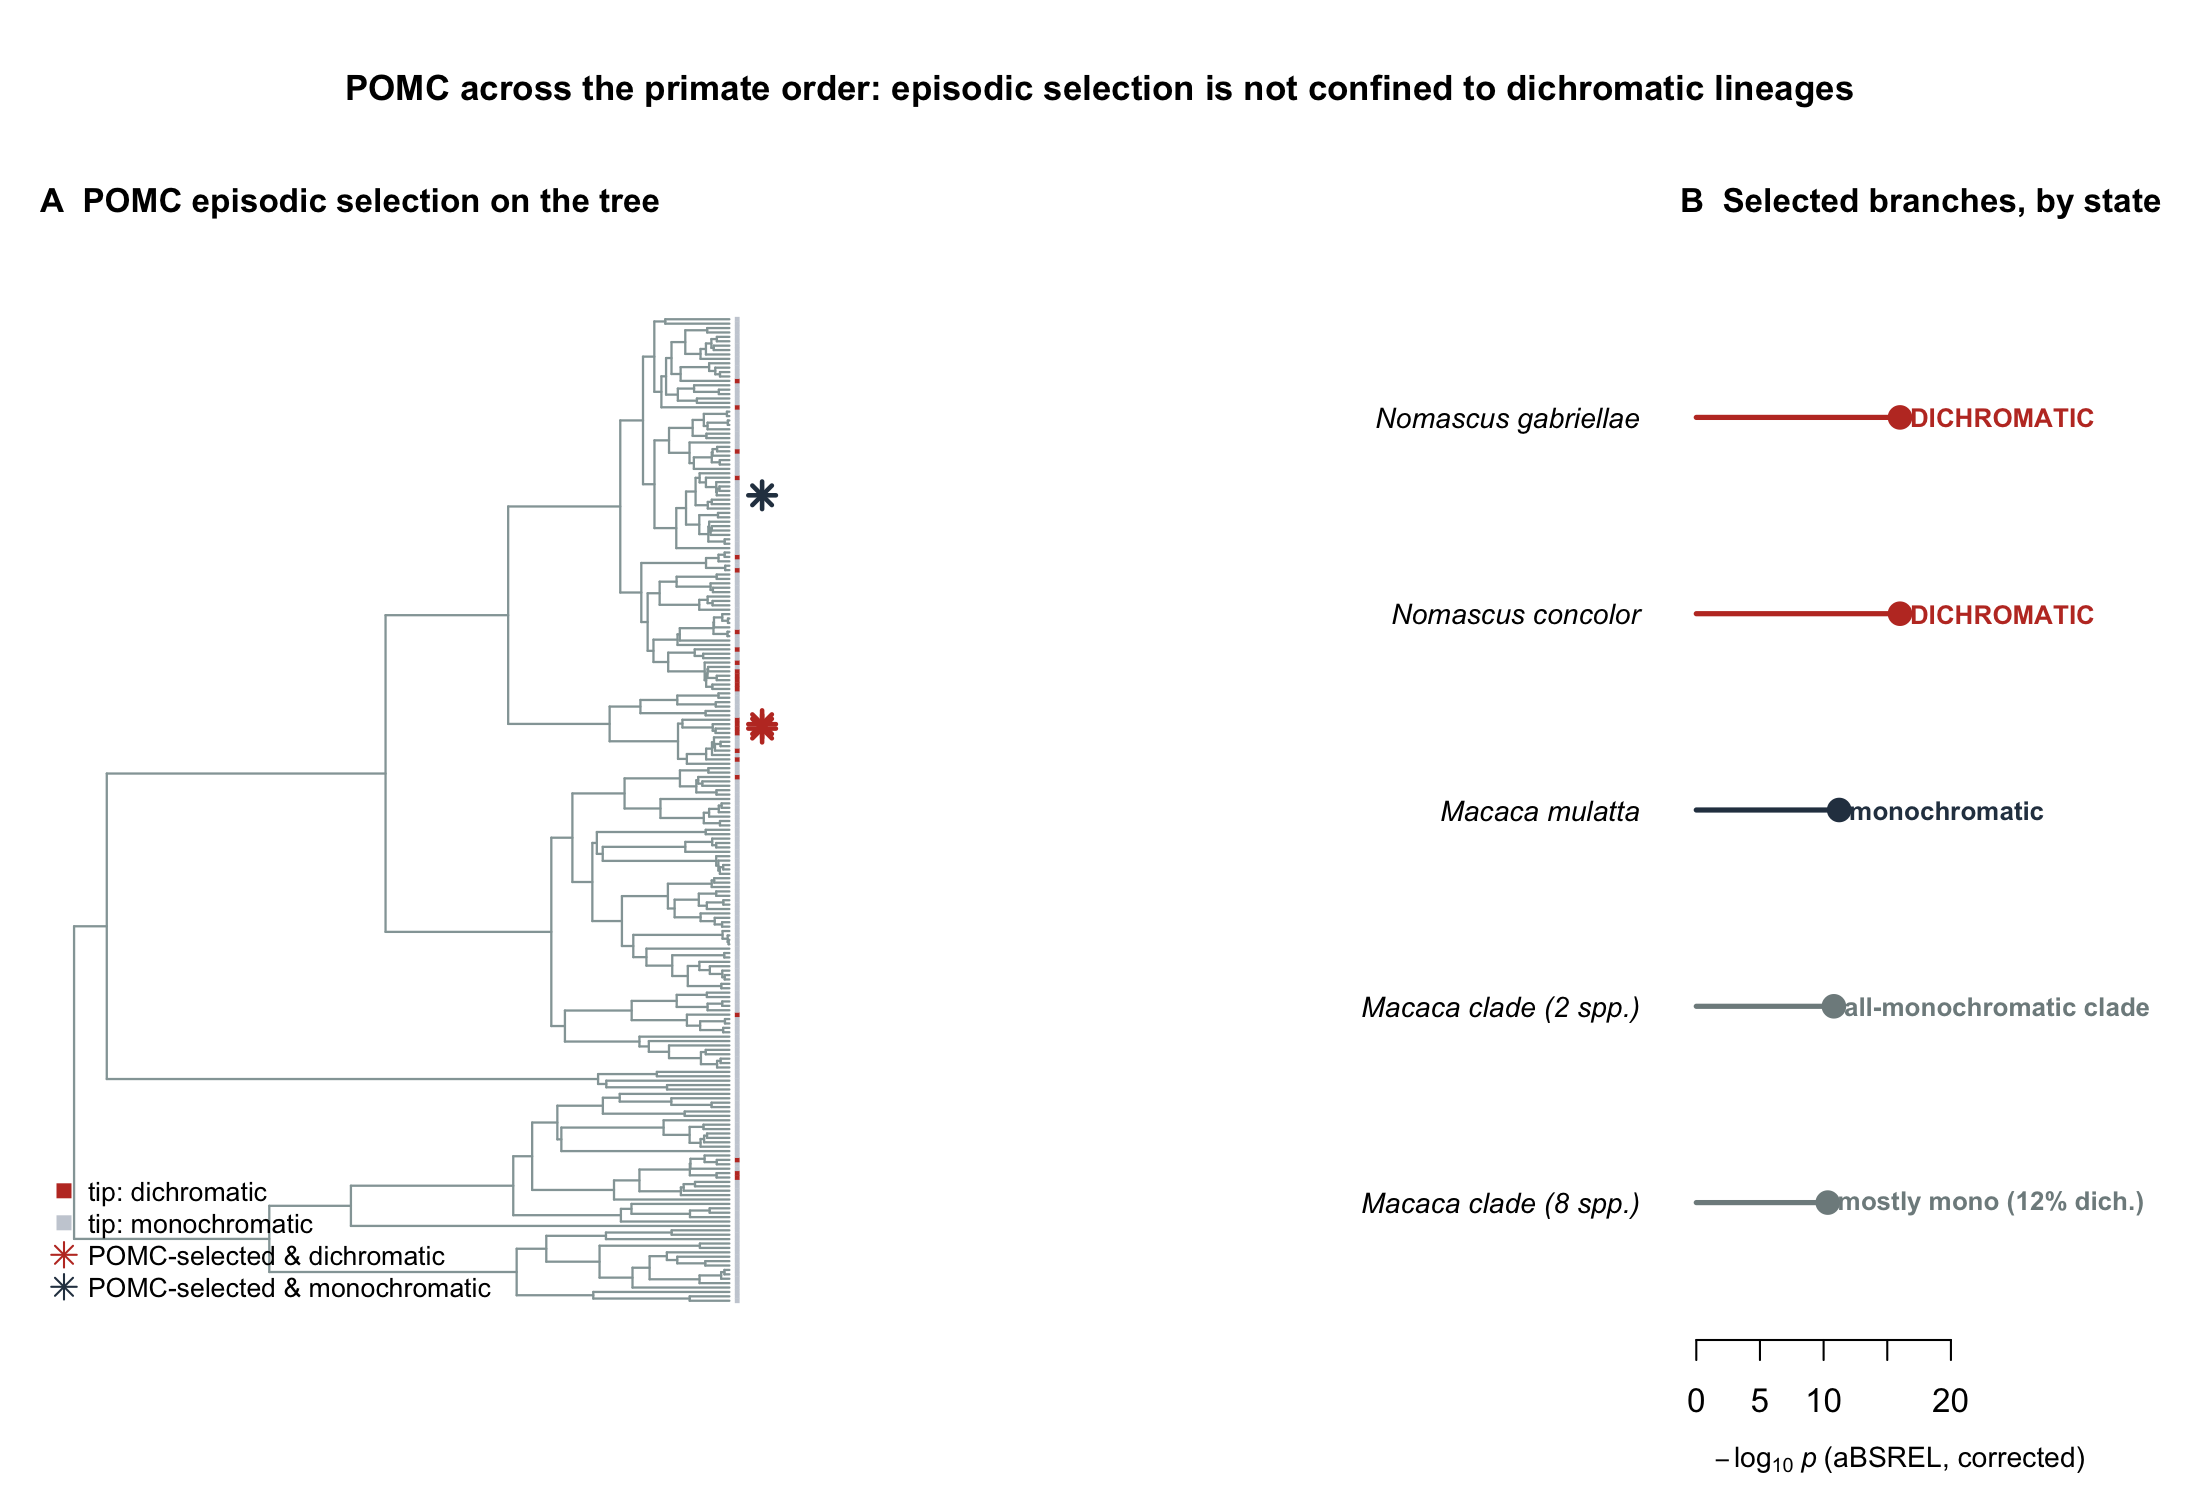

In [8]:
from IPython.display import Image, display
_pomc = os.path.join(SYN, "figures", "nb15_pomc_tree.png")
if os.path.exists(_pomc):
    display(Image(filename=_pomc))
else:
    print("nb15_pomc_tree.png not built yet - run nb15_pomc.R")

In [9]:
# POMC-specific selection evidence, printed from the frozen tables (panel-agnostic).
if PER_ORIGIN is not None:
    pk = PER_ORIGIN[PER_ORIGIN.gene == "POMC"][["origin_id", "module", "K", "p_BH"]]
    print("POMC per-origin RELAX:")
    print(pk.to_string(index=False))
if BRANCH is not None and "absrel_corrected_p" in BRANCH.columns:
    pb = BRANCH[BRANCH.gene == "POMC"].copy()
    pb["cp"] = pd.to_numeric(pb["absrel_corrected_p"], errors="coerce")
    sel = pb[pb.cp < 0.05][["branch", "is_tip", "cp"]]
    print(f"\nPOMC branches under episodic selection (aBSREL corrected p<0.05): {len(sel)}")
    print(sel.to_string(index=False))

POMC per-origin RELAX:
origin_id       module        K  p_BH
 origin_7 pigmentation 1.200991   1.0
 origin_8 pigmentation 3.388651   0.0

POMC branches under episodic selection (aBSREL corrected p<0.05): 5
             branch  is_tip           cp
     Macaca_mulatta    True 5.968559e-12
             Node42   False 4.725154e-11
             Node45   False 1.556683e-11
  Nomascus_concolor    True 0.000000e+00
Nomascus_gabriellae    True 0.000000e+00


## 6 — Convergence and divergence across independent origins

**The question.** If dichromatism arose ~15–19 times, do independent origins reach it through
the *same* genes (molecular convergence) or *different* ones (divergence)? This is the natural
test of the two-module hypothesis: convergence would say there is one genetic route;
divergence would say the coupled system can be perturbed at many points to the same phenotypic
end.

**Method and honest framing.** For each powered origin the gene set is those panel genes with
a significant per-origin selection-intensity shift (RELAX K, p_BH < 0.05); overlap between
origins is the shared-gene count. On the current panel (size printed by the cell below; the
clean-30 expansion is still landing), only **two** of the three powered origins carry a
detectable signal — *Trachypithecus* (a multi-gene, both-module set) and *Nomascus* (a small
hormone-leaning set around POMC) — and they share **zero** genes; *Eulemur* has none passing
threshold.
So where the comparison is well-powered it shows **divergence, not convergence**: independent
origins are built through different genes.

This is stated as divergence-where-powered, not as a clade-wide "no convergence" claim, because
the test is **power-limited**: with only two signalled origins, and the ~13–17 single-tip
origins recoverable only by branch scans (not per-origin RELAX), a broader convergence null
cannot be tested here. The overlap is recomputed live below and refreshes to 110 genes when the
clean-30 expansion lands (which can only *add* genes to an origin's set, so the zero-overlap
divergence result is robust unless a new gene happens to hit both origins).

In [10]:
# Per-origin gene-set overlap from the CURRENT perorigin_v1 tables (pre-expansion run; the
# printed panel size is the number of genes with RELAX results, refreshing to 110 when the
# clean-30 expansion lands). Gene set per origin = genes with p_BH<0.05.
import itertools
if PER_ORIGIN is not None and "p_BH" in PER_ORIGIN.columns:
    sig = PER_ORIGIN[PER_ORIGIN["p_BH"] < 0.05]
    sets = {o: set(sig[sig.origin_id == o].gene) for o in sorted(sig.origin_id.unique())}
    powered = sorted(PER_ORIGIN.origin_id.unique())
    print(f"powered origins tested: {powered}  (>=2 dichromatic tips each)")
    for o in powered:
        g = sorted(sets.get(o, set()))
        print(f"  {o}: {len(g)} genes under selection (p_BH<0.05) - {g if g else '(none pass threshold)'}")
    print()
    signalled = [o for o in powered if sets.get(o)]
    if len(signalled) >= 2:
        for a, b in itertools.combinations(signalled, 2):
            inter = sets[a] & sets[b]
            print(f"  {a} n {b}: {len(inter)} shared genes - {sorted(inter) if inter else 'ZERO overlap'}")
    else:
        print("  Only one origin carries a detectable multi-gene signal; a molecular-convergence")
        print("  test needs >=2 signalled origins, so the comparison is power-limited (see prose).")
    print(f"\n(Current: {PER_ORIGIN['gene'].nunique()}-gene panel. Refreshes when clean-30 lands -> 110 genes.)")
else:
    print("Awaiting per-origin tables with p_BH for the overlap recompute.")

powered origins tested: ['origin_14', 'origin_7', 'origin_8']  (>=2 dichromatic tips each)
  origin_14: 0 genes under selection (p_BH<0.05) - (none pass threshold)
  origin_7: 13 genes under selection (p_BH<0.05) - ['ASIP', 'EDN3', 'HPS4', 'HSD17B7', 'KISS1R', 'MC1R', 'SCARB1', 'SHBG', 'SPTLC2', 'SRD5A1', 'SRD5A3', 'TFAP2A', 'TYR']
  origin_8: 3 genes under selection (p_BH<0.05) - ['HGF', 'HRAS', 'POMC']

  origin_7 n origin_8: 0 shared genes - ZERO overlap

(Current: 106-gene panel. Refreshes when clean-30 lands -> 110 genes.)


## 7 — Synthesis

Sexual dichromatism in primates is a **labile, polygenic trait built from two coupled modules**.
It has arisen on the order of 15–19 times and is lost far faster than it is gained (§3). Where
its genetic basis can be tested, independent origins do not reuse the same genes (§4, §6), and
they differ in whether pigmentation or hormone-signalling genes carry the selection signal (§5).

That pattern is what the *network* framing predicts and what a single-gene framing would miss:
if dichromatism is the output of a coupled pigmentation–hormone system, there are many points at
which the system can be pushed to produce (or lose) the phenotype, and different lineages have
used different ones. The panel that makes this testable — which genes, and why — is built in
**NB14**, with the hormone layer developed in **NB13**. The selection evidence here is strongest
for the three powered origins; the single-tip origins and the convergence test are power-limited
and framed as such.